<table class="table table-bordered">
    <tr>
       <th style="text-align:center;"><h3>IS217 - Clustering</h3><h3>Newspaper Case Study</h3>    </tr>
</table>

### Learning Outcomes

At the end of this notebook, you should be able to:
<ul>
    <li>Apply <b>EDA</b> and the <b>K-means</b> Clustering algorithm on a `newspaper` dataset to uncover groups of readers.</li>
</ul>

The dataset used shows the result of a survey conducted on `n = 2,939` Chicago residents about the `time` spent reading newspapers during a week and the number of `sections` "read or looked into."<br />
(See Malthouse and Calder (2002) for an expanded version of this segmentation)

The dictionary of the data is as follows:
- `time` : Number of hours spent by the reader during the week.
- `section`: Number of sections "read or looked into" by the reader
- `people`: Number of the readers who answered (`time`, `section`) given in the same row.


Let's apply `EDA` and `K-means` clustering on the `np.csv` dataset to see if we can uncover some natural groupings of readers or reading habits.

In [1]:
#Install scikit-learn library
# !pip install scikit-learn

### First, let's import `pandas` and `numpy` libraries.

In [1]:
import pandas as pd
import numpy as np

### Read the newspaper dataset ('np.csv') into a `DataFrame`.

In [3]:
news = pd.read_csv('np.csv')
news.columns = ['time','sections','persons']

## 1.  `EDA` on the news `DataFrame` to get more insight 

In [4]:
news.head()

,time,sections,persons
0,0,0,370
1,1,0,9
2,1,1,127
3,1,2,119
4,1,3,55


In [5]:
# shows number of rows and number of columns
news.shape

(53, 3)

In [6]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   time      53 non-null     int64
 1   sections  53 non-null     int64
 2   persons   53 non-null     int64
dtypes: int64(3)
memory usage: 1.4 KB


In [7]:
# adding all the observations, context already gave n=2939
news['persons'].sum()

np.int64(2939)

### Think!

Why do sum function and info function give different number of 'persons'?

The sum function sums the number in 'persons', while info and shape functions give the number of rows in the dataset

### Let's now expand the dataset : Duplicate rows according to the number of persons.

Reference: 
1. DataFrame.values https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.values.html
2. Numpy.repeat https://numpy.org/devdocs/reference/generated/numpy.repeat.html

In [23]:
news_expanded = pd.DataFrame(news.values.repeat(news.persons, axis=0), columns=news.columns)

In [24]:
news_expanded.head()

,time,sections,persons
0,0,0,370
1,0,0,370
2,0,0,370
3,0,0,370
4,0,0,370


In [25]:
news_expanded.shape

(2939, 3)

### Check for missing values using `sum()` function.

<font color = 'blue'> Write some python code to determine if there are missing values in the dataset.</font><br />

Expected output:

    time        0
    sections    0
    persons     0
    dtype: int64

In [26]:
news_expanded.isnull().sum()

time        0
sections    0
persons     0
dtype: int64

So it doesn't seem to have missing values in the dataset.

Let's observe the statistics of the data. 

Take note of the `std` for `time` and `sections` variables.

In [27]:
news_expanded.describe()

,time,sections,persons
count,2939.000000,2939.000000,2939.000000
mean,3.370534,3.394012,103.913916
std,2.369500,2.253787,104.837641
min,0.000000,0.000000,1.000000
25%,1.000000,2.000000,47.000000
50%,3.000000,3.000000,67.000000
75%,6.000000,5.000000,103.000000
max,7.000000,7.000000,370.000000


Now we know that column `persons` is referring to the aggregated value. We need to use this cautiously, for example, summing up the column does not make sense. 

###  Visualizations to understand the dataset better

For that let's import matplotlib and seaborn libraries.

In [28]:
import seaborn as sns
%matplotlib inline 
import matplotlib.pyplot as plt

#### a. Visualisation of the 'sections' variable : Kernel Density Estimation

<Axes: xlabel='sections', ylabel='Density'>

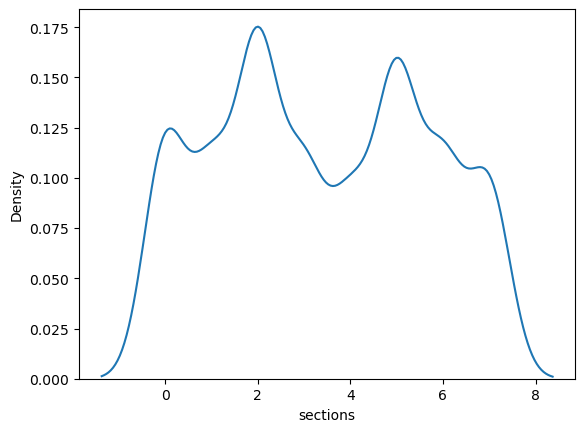

In [29]:
sns.kdeplot(news_expanded['sections'])

### Think!
Where are the peaks? What is your interpretation?

We can see some peaks in the curve: 
- 0 sections
- 2 sections
- 5 sections
- 7 sections maybe

There is large number of people who do not read newspaper. There are many people reading only 2 sections while also quite a large number of people reading 5 sections. 

#### b. Visualisation of the 'time' variable : KDE

<Axes: xlabel='time', ylabel='Density'>

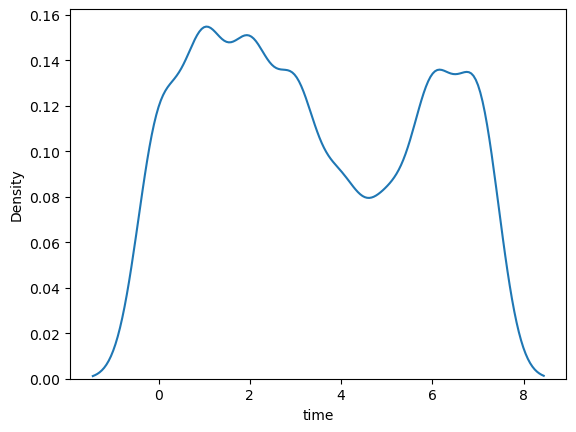

In [30]:
sns.kdeplot(news_expanded['time'])

### Think! 
What is your observation about time spent on newspaper?

There are two major groups of readers, those who: 
- spent less time reading: between 0 and 3 hrs
- spent more time reading: bewteen 6 and 7 hrs

Better to give a range, eg peak is between 0 and 3, because peak is not exactly at the whole number

#### c. Visualisation of both 'sections' and 'time' variables : Scatter Plot

<Axes: xlabel='sections', ylabel='time'>

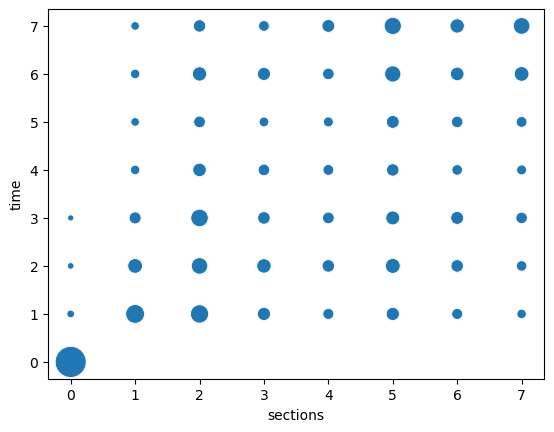

In [31]:
sns.scatterplot(x='sections', y='time', data=news_expanded, size='persons', sizes=(20, 500),legend = False)

### Think!
Where are the concentrations? What can you say about the readers?

We can see some concentrations around:

- 0 section and 0 min
- 1 to 3 sections and 1 to 3 hrs
- 2 to 4 sections and 6 to 7 hrs
- 5 to 6 sections and 1 to 3 hrs
- 5 to 7 sections and 6 to 7 hrs

#### d. Other way to visualize `sections` vs `time` is with `joinplot()` of `seaborn` lib.

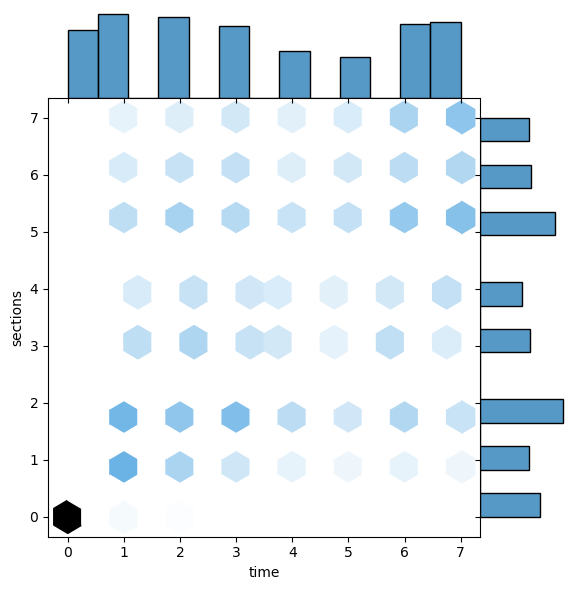

In [32]:
sns.jointplot(x='time', y='sections', data=news_expanded, kind="hex",height=6, space=0)

Please refer to the documentation : https://seaborn.pydata.org/generated/seaborn.jointplot.html

#### e. Clearer insights about the different newspaper habits ( `jointplot()` and `kde`)

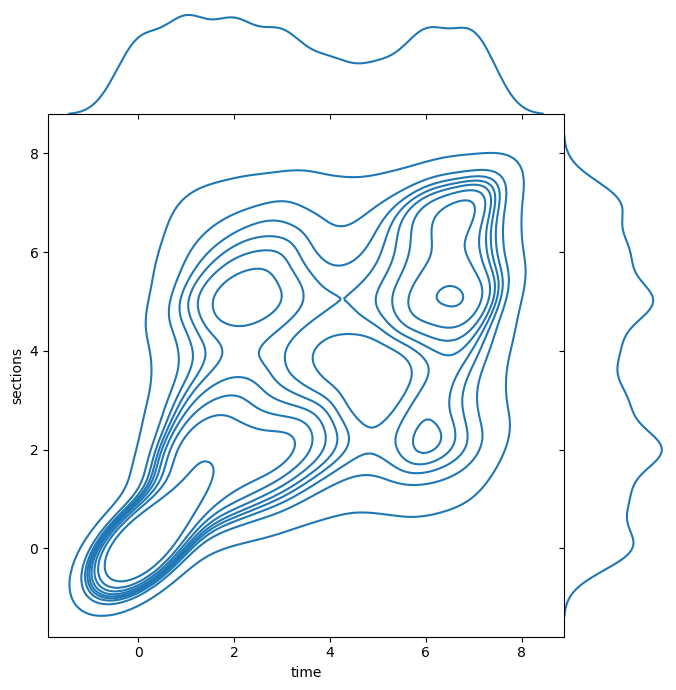

In [33]:
sns.jointplot(x='time', y='sections', data=news_expanded, kind="kde",height=7, space=0)

### Think!
What is your observation this time? Where are the concentrations? 

It is clearer in the KDE visual than with the other visualisations. We can see the concentrations around:

- 0 section and 0 min
- 2 sections and 2 hrs
- 2 sections and 5 hrs
- 6 sections and 2 hrs
- 7 sections and 6 hrs

## 2. K-means Clustering Algorithm using sklearn library 

In this section, we will use the `SciKit Learn` library that provides useful functions related to the clustering technics.<br />
For more information on `K-Mean` functions of the `SciKit Learn` library, please refer to the following documentation:
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

### First, let's import the `KMeans` library

In [34]:
from sklearn.cluster import KMeans

First, let's use slicing to `news_updated` `DataFrame` to keep only the first 2 columns `time` and `sections` and remove the last column `persons`.

In [35]:
news_2var = news_expanded.iloc[:,0:2]
news_2var.head()

,time,sections
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


### Now let's create a model by applying K-means algorithm (K=5)

Let's explore the `KMeans` Library provided by Scikit-Learn.  <br />
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html <br />
In this section we will understand the following parameters: <br />
- n_clusters
- n_init
- max_iter
- tol
- random_state
<br />

Note: Current Scikit-Learn KMeans implementation uses only Euclidean distance measure. Use another library such as NLTK if another distance measure (e.g., Cosine similarity) is required. <br />

In [36]:
# Apply K-Means with K=5 and set a random_state so that the result is repeatable.
model_5 = KMeans(n_clusters = 5, random_state=0)
type(model_5)

sklearn.cluster._kmeans.KMeans

### Now let's compute K-means clustering using the `fit()` fonction

The `fit()` function of `KMeans` Library runs the model by computing the `K-means` clustering algorithm. For that, we will provide to the `fit()` function the `DataFrame` `news_2var` that contains only the columns `time` and `sections`. <br />
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

By using most of the default values, we run K-means using the following parameters:  max iteration = 300, n_init = 10, tolerance to 0.0001 (stop iterating when tolerance is met) .

In [37]:
model_5.fit(news_2var)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


### Profile and evaluate the clustering model  

Firstly, get the center of the centroids for the 5 clusters. <br >
For that we can use the attribute `cluster_centers_` of `KMeans` library.

In [38]:
model_5.cluster_centers_

array([[2.39655172, 5.4200627 ],
       [2.7844523 , 2.36749117],
       [6.09579439, 2.67056075],
       [0.57857143, 0.62428571],
       [6.23887974, 5.92586491]])

### Think!
How would you profile (interpret) the cluster based on cluster means? Provide a name to describe each cluster.

Solution:

skimmers
light readers
selective readers
non readers
heavy readers

### Think!
Can you draw similarities with the results with the KDE graph in part d?

The cluster profiles fit the observations in KDE graph. 

### Check for Convergence

Did the clustering model converge?

In [29]:
# Checking how many iterations was run
model_5.n_iter_

4

Yes. Since the max iteration for the algorithm was 300 and the model used only 4 iterations, the model did converge.

### Think!
Would the clustering result change with different random seeds?

In [ ]:
# Testing K-Means with K=5 and a different random_state.
#model_51 = KMeans(n_clusters = 5, random_state=[fill in your favourite number])
#model_51.fit(news_2var)
#model_51.cluster_centers_

In [ ]:
# Testing K-Means with K=5 and a different random_state.
#model_52 = KMeans(n_clusters = 5, random_state=[fill in a second favourite number])
#model_52.fit(news_2var)
#model_52.cluster_centers_

### Cluster labels for the K clusters 

The attibute `labels_` of `KMeans` will provide labels for each cluster.

In [ ]:
labels = model_5.labels_
labels

The labels are actually the clusters' numbers. So let's add those labels to the data frame `news_expanded`. 

In [ ]:
news_expanded['cluster'] = model_5.labels_

In [ ]:
news_expanded.head()

In [ ]:
news_expanded.tail()

You can see that the last column specifies the cluster number.

### Clusters Visualisation using seaborn and `lmplot()`

The `lmplot()` function is a very useful plotting function from `seaborn` for visualising clusters.<br />
Please refer to the documentation for more details:
https://seaborn.pydata.org/generated/seaborn.lmplot.html

In [ ]:
sns.lmplot( x="sections", y="time", data=news_expanded, fit_reg= False, hue='cluster', legend=True)

We can compare this graph with the `scatter plot` graph, where we use the `hue=cluster` argument to highlight the clusters in the graph.

In [ ]:
sns.scatterplot(x = 'sections', y = 'time', data = news_expanded, size= 'persons', legend = False , sizes = (20, 500), hue ='cluster')

Please refer to the documentation for more details:
https://seaborn.pydata.org/generated/seaborn.scatterplot.html

### Evaluating Clustering Result using Within Cluster SSE for K = 5  

The attribute `inertia_` of `KMeans` computes the sum of squared distances of observations to their closest cluster center. So in other words, `inertia_` is the sum of square errors (`SSE`) within clusters.

`SSE` is obtained with the attribute `inertia` of KMeans

In [ ]:
model_5.inertia_ 

In [ ]:
# Show the standard deviation for each cluster and each variable 
# We are not interested in the variable person, so use iloc to drop the column
news_expanded.groupby(['cluster']).std().iloc[:,0:2]

### Think!
Now we have Cluster Standard Deviations for each variable and each cluster. <br />
What do these numbers tell us about the clusters compared to the standard deviation without clustering?

The variances (or standard deviations) is less in each cluster compared to the variance in the initial dataset without cluster. We can also use the result to assess which cluster is more homogeneous. 

In [ ]:
# Check the cluster sizes
news_expanded.groupby(['cluster']).count()

### Think!

- What can you say about the cluster sizes?
- Are the sizes reasonably balanced?
- Is balanced cluster sizes desirable in clustering for this scenario?

- Cluster sizes are quite well balanced
- For this scenario, this is desirable as we hope to achieve clusters with similar number of observations so that actions or decisions can be taken for a group to yield similar impact

### [To be continued next lesson] Finding the value of K using Elbow Method 

We want to visualise using K-graph, i.e., plot `K` vs `SSE`

Now let's run the `K-means` algorithm <b>14 times</b>, for a value of K from <b>1</b> to <b>14</b>. <br />
For each iteration, we save the value of `SSE` (inertia).

In [ ]:
# Create a list to store SSE values
SSE = []
# Run K-means algorithm from K=1 to 14
for i in range(1,15):
    model = KMeans(n_clusters = i, random_state=0)
    model.fit(news_2var)
    SSE.append(model.inertia_)

In [ ]:
SSE

We can then plot the result of the obtained series:

In [ ]:
plt.plot(range(1,15), SSE, linewidth=2.0)
plt.xlabel('k')
plt.ylabel('SSE')

### Think!
What value of K seems optimum?

Put your answer below:

    - 

### Evaluate Clustering and Finding value of K using Silhouette Method

In [ ]:
# Import
from sklearn.metrics import silhouette_score

# run KMeans for k = 2 to k = 10
sil = []
for i in range(2,11):
    clusterer = KMeans(n_clusters= i, random_state=0)
    preds = clusterer.fit(news_2var)
    sil.append(silhouette_score(news_2var, preds.labels_))

# Print the array just to check the values
print (sil)

# Plotting the graph with Silhouette Coefficients
k = (range(2,11))
plt.title('Silhouette Coefficient Curve')
plt.xlabel('k')
plt.ylabel('SIL')
plt.plot(k, sil)

Very often, the selection of K comes with some experience and take into considerations of other factors such as 
- Domain knowledge
- Experiences
- Gut feel
- Overheads of managing additional cluster e.g., another cluster means another marketing strategy or policy

### Assess clustering improvement using Between_SS

The total variance in your data set that is explained by the clustering can be computed by between_SS, the difference between TSS and WSS. i.e.,

between_SS = TSS - WSS

By assigning the samples to k clusters, the model achieves a reduction in sums of squares of by (between_SS/ TSS)%.

In [ ]:
# Compare the improvement of clustering by the measure of the total variance 
# Note: If K = 1, there is no clustering, hence Total SSE is given by the inertia of the model when k=1

between_ss = []
for i in range(1,15):
    between_ss.append(((SSE[0]-SSE[i-1]) / SSE[0]) * 100)
    
print(*between_ss, sep = "\n")

With between_SS, you can compare models across different distance measures, random seeds, or use it to decide the appropriate 𝑘 value by selecting the one that achieves the desired percentage of improvement provided by the clustering model.